In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train = pd.read_csv("train_ctrUa4K.csv")
test = pd.read_csv("test_lAUu6dG.csv")

In [3]:
print("Train Shape:", train.shape)
print("Test Shape :", test.shape)

Train Shape: (614, 13)
Test Shape : (367, 12)


In [4]:
train.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [5]:
train.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


In [6]:
test.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [7]:
test.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
362,LP002971,Male,Yes,3+,Not Graduate,Yes,4009,1777,113.0,360.0,1.0,Urban
363,LP002975,Male,Yes,0,Graduate,No,4158,709,115.0,360.0,1.0,Urban
364,LP002980,Male,No,0,Graduate,No,3250,1993,126.0,360.0,NaN,Semiurban
365,LP002986,Male,Yes,0,Graduate,No,5000,2393,158.0,360.0,1.0,Rural
366,LP002989,Male,No,0,Graduate,Yes,9200,0,98.0,180.0,1.0,Rural


In [8]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 83.4 KB


In [9]:
import warnings
warnings.filterwarnings("ignore")

In [10]:
train.describe(include="object")

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP001002,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


In [11]:
print("Training Columns:")
print(train.columns.tolist())

print("\nTest Columns:")
print(test.columns.tolist())

Training Columns:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

Test Columns:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']


In [12]:
train.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [13]:
categorical_missing = [
    "Gender",
    "Married",
    "Dependents",
    "Self_Employed",
    "Credit_History"
]

# Numerical columns
numerical_missing = [
    "LoanAmount",
    "Loan_Amount_Term"
]

In [14]:
for column in categorical_missing:
    train[column] = train[column].fillna(
        train[column].mode()[0]
    )

    test[column] = test[column].fillna(
        train[column].mode()[0]
    )

In [15]:
for column in numerical_missing:
    train[column] = train[column].fillna(
        train[column].median()
    )

    test[column] = test[column].fillna(
        train[column].median()
    )

In [16]:
train.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [17]:
print("Number of duplicate rows:", train.duplicated().sum())

Number of duplicate rows: 0


In [18]:
print("Duplicate Loan IDs:", train["Loan_ID"].duplicated().sum())

Duplicate Loan IDs: 0


In [19]:
print(train["Loan_Status"].value_counts())

Loan_Status
Y    422
N    192
Name: count, dtype: int64


In [20]:
print(
    train["Loan_Status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Loan_Status
Y    68.73
N    31.27
Name: proportion, dtype: float64


### Target Visualization

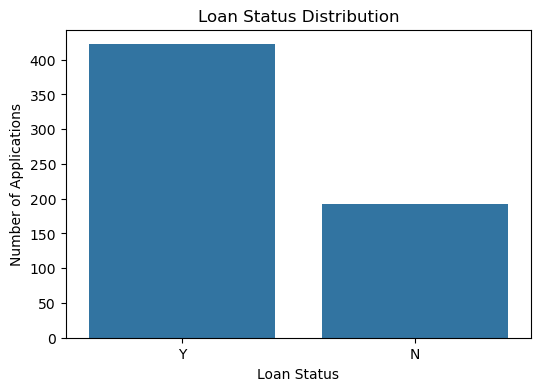

In [21]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=train,
    x="Loan_Status"
)

plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applications")

plt.show()

### Correlation Analysis

In [22]:
numerical_columns = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term"
]


In [23]:
categorical_columns = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Credit_History",
    "Property_Area"
]

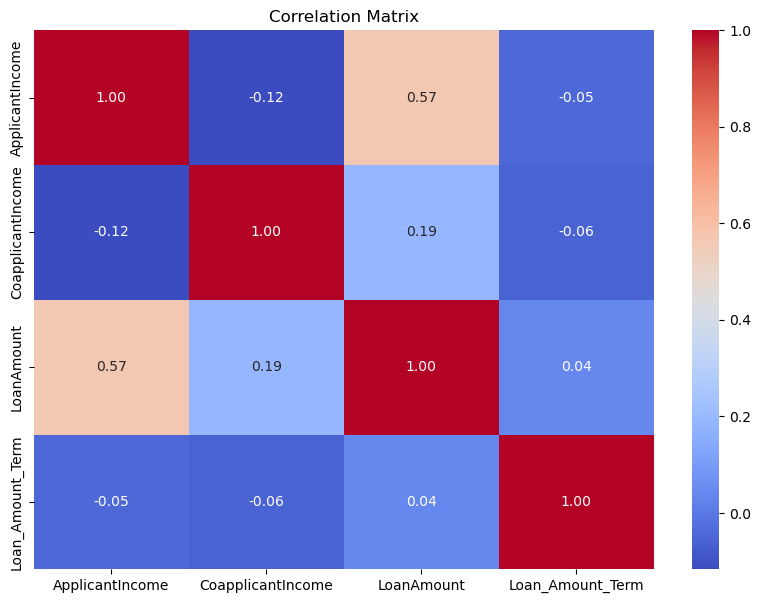

In [24]:
plt.figure(figsize=(10, 7))

correlation = train[numerical_columns].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

### Feature Engineering

In [25]:
train["TotalIncome"] = (
    train["ApplicantIncome"] +
    train["CoapplicantIncome"]
)

test["TotalIncome"] = (
    test["ApplicantIncome"] +
    test["CoapplicantIncome"]
)

display(
    train[
        [
            "ApplicantIncome",
            "CoapplicantIncome",
            "TotalIncome"
        ]
    ].head()
)

,ApplicantIncome,CoapplicantIncome,TotalIncome
0,5849,0.0,5849.0
1,4583,1508.0,6091.0
2,3000,0.0,3000.0
3,2583,2358.0,4941.0
4,6000,0.0,6000.0


In [26]:
train["IncomeLoanRatio"] = (
    train["TotalIncome"] /
    (train["LoanAmount"] + 1)
)

test["IncomeLoanRatio"] = (
    test["TotalIncome"] /
    (test["LoanAmount"] + 1)
)

display(
    train[
        [
            "TotalIncome",
            "LoanAmount",
            "IncomeLoanRatio"
        ]
    ].head()
)

,TotalIncome,LoanAmount,IncomeLoanRatio
0,5849.0,128.0,45.341085
1,6091.0,128.0,47.217054
2,3000.0,66.0,44.776119
3,4941.0,120.0,40.834711
4,6000.0,141.0,42.253521


In [27]:
from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

In [28]:
encoder = LabelEncoder()

for column in categorical_columns:

    train[column] = encoder.fit_transform(
        train[column]
    )

    test[column] = encoder.transform(
        test[column]
    )

In [29]:
display(train.head())

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,IncomeLoanRatio
0,LP001002,1,0,0,0,0,5849,0.0,128.0,360.0,1,2,Y,5849.0,45.341085
1,LP001003,1,1,1,0,0,4583,1508.0,128.0,360.0,1,0,N,6091.0,47.217054
2,LP001005,1,1,0,0,1,3000,0.0,66.0,360.0,1,2,Y,3000.0,44.776119
3,LP001006,1,1,0,1,0,2583,2358.0,120.0,360.0,1,2,Y,4941.0,40.834711
4,LP001008,1,0,0,0,0,6000,0.0,141.0,360.0,1,2,Y,6000.0,42.253521


### Encode Target Variable

In [30]:
train["Loan_Status"] = train["Loan_Status"].map({
    "Y": 1,
    "N": 0
})

print(
    train["Loan_Status"].value_counts()
)

Loan_Status
1    422
0    192
Name: count, dtype: int64


In [31]:
X = train.drop(
    ["Loan_ID", "Loan_Status"],
    axis=1
)

y = train["Loan_Status"]

X_test = test.drop(
    ["Loan_ID"],
    axis=1
)

print("X Shape:", X.shape)
print("y Shape:", y.shape)
print("X_test Shape:", X_test.shape)

X Shape: (614, 13)
y Shape: (614,)
X_test Shape: (367, 13)


In [32]:
print(X.dtypes)

Gender                 int64
Married                int64
Dependents             int64
Education              int64
Self_Employed          int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History         int64
Property_Area          int64
TotalIncome          float64
IncomeLoanRatio      float64
dtype: object


In [33]:
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)

In [34]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)

X_train: (491, 13)
X_valid: (123, 13)
y_train: (491,)
y_valid: (123,)


### Feature Scaling

In [35]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_valid_scaled = scaler.transform(
    X_valid
)

X_test_scaled = scaler.transform(
    X_test
)

In [36]:
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

display(
    X_train_scaled_df.head()
)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,TotalIncome,IncomeLoanRatio
0,0.464054,-1.380335,-0.748586,-0.540468,-0.394074,-0.352802,-0.563228,-1.131588,0.280691,0.397516,1.222039,-0.575168,0.425374
1,0.464054,0.724462,0.250207,-0.540468,-0.394074,-0.343346,-0.563228,-0.592309,0.280691,0.397516,-0.043828,-0.566044,-0.495433
2,0.464054,0.724462,1.249000,-0.540468,-0.394074,-0.339471,0.050405,0.040758,0.280691,-2.515623,-1.309696,-0.306544,-0.518168
3,0.464054,0.724462,0.250207,1.850250,-0.394074,-0.445963,-0.024953,-0.393010,-2.486768,-2.515623,-1.309696,-0.440706,-0.425365
4,0.464054,0.724462,-0.748586,-0.540468,-0.394074,-0.451078,0.234495,0.040758,0.280691,0.397516,-0.043828,-0.337505,-0.560772


### Logistic Regression

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [38]:
logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

logistic_pred = logistic_model.predict(
    X_valid_scaled
)

logistic_accuracy = accuracy_score(
    y_valid,
    logistic_pred
)

print(
    "Logistic Regression Accuracy:",
    round(logistic_accuracy, 4)
)

Logistic Regression Accuracy: 0.8618


In [39]:
print(
    classification_report(
        y_valid,
        logistic_pred
    )
)

              precision    recall  f1-score   support

           0       0.96      0.58      0.72        38
           1       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



### Decision Tree

In [40]:
from sklearn.tree import DecisionTreeClassifier

In [41]:
decision_tree = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=5,
    random_state=42
)

decision_tree.fit(
    X_train_scaled,
    y_train
)

dt_pred = decision_tree.predict(
    X_valid_scaled
)

dt_accuracy = accuracy_score(
    y_valid,
    dt_pred
)

print(
    "Decision Tree Accuracy:",
    round(dt_accuracy, 4)
)

Decision Tree Accuracy: 0.8211


### Random Forest

In [42]:
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)

In [43]:
random_forest = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=3,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

random_forest.fit(
    X_train_scaled,
    y_train
)

rf_pred = random_forest.predict(
    X_valid_scaled
)

rf_accuracy = accuracy_score(
    y_valid,
    rf_pred
)

print(
    "Random Forest Accuracy:",
    round(rf_accuracy, 4)
)

Random Forest Accuracy: 0.8699


In [44]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        logistic_accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

model_results = model_results.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

display(model_results)

,Model,Accuracy
0,Random Forest,0.869919
1,Logistic Regression,0.861789
2,Decision Tree,0.821138


### Confusion Matrix

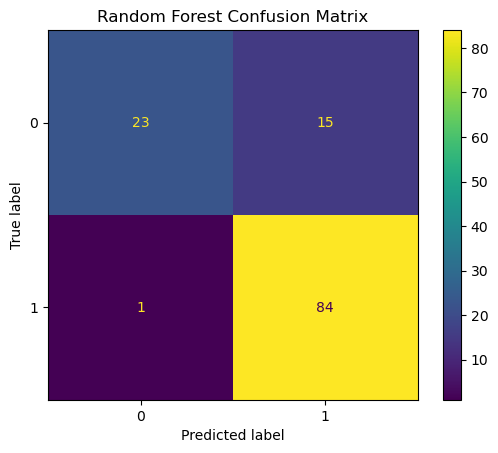

In [45]:
cm = confusion_matrix(
    y_valid,
    rf_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Random Forest Confusion Matrix")

plt.show()

In [46]:
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, None],
    "min_samples_leaf": [1, 2, 3, 5],
    "max_features": ["sqrt", "log2"]
}

In [47]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),

    param_grid=rf_param_grid,

    scoring="accuracy",

    cv=5,

    n_jobs=-1,

    verbose=1
)

grid_search.fit(
    X_train_scaled,
    y_train
)

Fitting 5 folds for each of 96 candidates, totalling 480 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [3, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [48]:
final_model = grid_search.best_estimator_

print(
    "Final model:",
    final_model
)

Final model: RandomForestClassifier(max_depth=3, n_jobs=-1, random_state=42)


In [49]:
final_model.fit(
    X_train_scaled,
    y_train
)

,n_estimators,100
,criterion,'gini'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [50]:
final_scaler = StandardScaler()

X_scaled = final_scaler.fit_transform(X)

X_test_final_scaled = final_scaler.transform(
    X_test
)

# Train final model on complete training data
final_model.fit(
    X_scaled,
    y
)

# Predict test data
test_predictions = final_model.predict(
    X_test_final_scaled
)

# Convert 1/0 to Y/N
loan_status_predictions = np.where(
    test_predictions == 1,
    "Y",
    "N"
)

print(
    "Predictions generated:",
    len(loan_status_predictions)
)

Predictions generated: 367


In [51]:
submission = pd.DataFrame({
    "Loan_ID": test["Loan_ID"],
    "Loan_Status": loan_status_predictions
})

# Save submission
submission.to_csv(
    "loan_eligibility_submission.csv",
    index=False
)

# Display submission
display(
    submission.head(10)
)

# ============================================================
# VALIDATION
# ============================================================

print("Submission Shape:", submission.shape)

print(
    "\nSubmission Columns:",
    submission.columns.tolist()
)

print(
    "\nMissing Loan_ID:",
    submission["Loan_ID"].isnull().sum()
)

print(
    "Missing Loan_Status:",
    submission["Loan_Status"].isnull().sum()
)

print(
    "\nPrediction Distribution:"
)

print(
    submission["Loan_Status"].value_counts()
)

# Assertions
assert list(submission.columns) == [
    "Loan_ID",
    "Loan_Status"
]

assert len(submission) == len(test)

assert submission["Loan_ID"].isnull().sum() == 0

assert submission["Loan_Status"].isnull().sum() == 0

assert set(
    submission["Loan_Status"].unique()
).issubset({"Y", "N"})


,Loan_ID,Loan_Status
0,LP001015,Y
1,LP001022,Y
2,LP001031,Y
3,LP001035,Y
4,LP001051,Y
5,LP001054,Y
6,LP001055,Y
7,LP001056,N
8,LP001059,Y
9,LP001067,Y


Submission Shape: (367, 2)

Submission Columns: ['Loan_ID', 'Loan_Status']

Missing Loan_ID: 0
Missing Loan_Status: 0

Prediction Distribution:
Loan_Status
Y    302
N     65
Name: count, dtype: int64
